In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Data Overview

Assumptions:
Data are not manipulated


In [4]:
df=pd.read_csv("insurance_claims.csv")
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 40 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   months_as_customer           1000 non-null   int64  
 1   age                          1000 non-null   int64  
 2   policy_number                1000 non-null   int64  
 3   policy_bind_date             1000 non-null   object 
 4   policy_state                 1000 non-null   object 
 5   policy_csl                   1000 non-null   object 
 6   policy_deductable            1000 non-null   int64  
 7   policy_annual_premium        1000 non-null   float64
 8   umbrella_limit               1000 non-null   int64  
 9   insured_zip                  1000 non-null   int64  
 10  insured_sex                  1000 non-null   object 
 11  insured_education_level      1000 non-null   object 
 12  insured_occupation           1000 non-null   object 
 13  insured_hobbies    

,months_as_customer,age,policy_number,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,capital-gains,capital-loss,incident_hour_of_the_day,number_of_vehicles_involved,bodily_injuries,witnesses,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_year,_c39
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,0.0
mean,203.954000,38.948000,546238.648000,1136.000000,1256.406150,1.101000e+06,501214.488000,25126.100000,-26793.700000,11.644000,1.83900,0.992000,1.487000,52761.94000,7433.420000,7399.570000,37928.950000,2005.103000,NaN
std,115.113174,9.140287,257063.005276,611.864673,244.167395,2.297407e+06,71701.610941,27872.187708,28104.096686,6.951373,1.01888,0.820127,1.111335,26401.53319,4880.951853,4824.726179,18886.252893,6.015861,NaN
min,0.000000,19.000000,100804.000000,500.000000,433.330000,-1.000000e+06,430104.000000,0.000000,-111100.000000,0.000000,1.00000,0.000000,0.000000,100.00000,0.000000,0.000000,70.000000,1995.000000,NaN
25%,115.750000,32.000000,335980.250000,500.000000,1089.607500,0.000000e+00,448404.500000,0.000000,-51500.000000,6.000000,1.00000,0.000000,1.000000,41812.50000,4295.000000,4445.000000,30292.500000,2000.000000,NaN
50%,199.500000,38.000000,533135.000000,1000.000000,1257.200000,0.000000e+00,466445.500000,0.000000,-23250.000000,12.000000,1.00000,1.000000,1.000000,58055.00000,6775.000000,6750.000000,42100.000000,2005.000000,NaN
75%,276.250000,44.000000,759099.750000,2000.000000,1415.695000,0.000000e+00,603251.000000,51025.000000,0.000000,17.000000,3.00000,2.000000,2.000000,70592.50000,11305.000000,10885.000000,50822.500000,2010.000000,NaN
max,479.000000,64.000000,999435.000000,2000.000000,2047.590000,1.000000e+07,620962.000000,100500.000000,0.000000,23.000000,4.00000,2.000000,3.000000,114920.00000,21450.000000,23670.000000,79560.000000,2015.000000,NaN


In [5]:
df.isna().sum()

months_as_customer                0
age                               0
policy_number                     0
policy_bind_date                  0
policy_state                      0
policy_csl                        0
policy_deductable                 0
policy_annual_premium             0
umbrella_limit                    0
insured_zip                       0
insured_sex                       0
insured_education_level           0
insured_occupation                0
insured_hobbies                   0
insured_relationship              0
capital-gains                     0
capital-loss                      0
incident_date                     0
incident_type                     0
collision_type                    0
incident_severity                 0
authorities_contacted            91
incident_state                    0
incident_city                     0
incident_location                 0
incident_hour_of_the_day          0
number_of_vehicles_involved       0
property_damage             

In [51]:
df[df["authorities_contacted"].isna()]["fraud"].sum()

np.int64(6)

In [6]:
df.duplicated().sum() 

np.int64(0)

In [54]:
df[df["fraud"]==1]["total_claim_amount"].sum()

np.int64(14894620)

# Data Cleaning

In [7]:
# drop c_39
df.drop("_c39", axis =1, inplace=True)

In [8]:
# change date in data object
df["policy_bind_date"] = pd.to_datetime(df["policy_bind_date"])
df["incident_date"] = pd.to_datetime(df['incident_date'])

In [9]:
expl_col = df.describe().columns #columns with explanatory variable

In [10]:
expl_col

Index(['months_as_customer', 'age', 'policy_number', 'policy_bind_date',
       'policy_deductable', 'policy_annual_premium', 'umbrella_limit',
       'insured_zip', 'capital-gains', 'capital-loss', 'incident_date',
       'incident_hour_of_the_day', 'number_of_vehicles_involved',
       'bodily_injuries', 'witnesses', 'total_claim_amount', 'injury_claim',
       'property_claim', 'vehicle_claim', 'auto_year'],
      dtype='object')

### String Data Cleaning 

In [11]:
#check string objects
for col in df.drop(expl_col, axis=1).columns:
    if col != "incident_location":
        print(df[col].value_counts())

policy_state
OH    352
IL    338
IN    310
Name: count, dtype: int64
policy_csl
250/500     351
100/300     349
500/1000    300
Name: count, dtype: int64
insured_sex
FEMALE    537
MALE      463
Name: count, dtype: int64
insured_education_level
JD             161
High School    160
Associate      145
MD             144
Masters        143
PhD            125
College        122
Name: count, dtype: int64
insured_occupation
machine-op-inspct    93
prof-specialty       85
tech-support         78
sales                76
exec-managerial      76
craft-repair         74
transport-moving     72
priv-house-serv      71
other-service        71
armed-forces         69
adm-clerical         65
protective-serv      63
handlers-cleaners    54
farming-fishing      53
Name: count, dtype: int64
insured_hobbies
reading           64
exercise          57
paintball         57
bungie-jumping    56
movies            55
camping           55
golf              55
kayaking          54
yachting          53
hiking     

### In these cases are unknown ? values
- property_damage :  ['YES' '?' 'NO']
- police_report_available :  ['YES' '?' 'NO']
- collision_type :  ['Side Collision' '?' 'Rear Collision' 'Front Collision']

In [12]:
print(df["property_damage"].value_counts())

print(df["police_report_available"].value_counts())

print(df["collision_type"].value_counts())

property_damage
?      360
NO     338
YES    302
Name: count, dtype: int64
police_report_available
?      343
NO     343
YES    314
Name: count, dtype: int64
collision_type
Rear Collision     292
Side Collision     276
Front Collision    254
?                  178
Name: count, dtype: int64


In [13]:
# for data viz: check if data of fraud reported is complete
print(df['fraud_reported'].unique())
# for dataviz: is it correlated?
df["fraud"]=df["fraud_reported"].apply(lambda x: 1 if str(x)=="Y" else 0)

['Y' 'N']


In [14]:
df["fraud"].sum()/1000


np.float64(0.247)

## Data Visualization

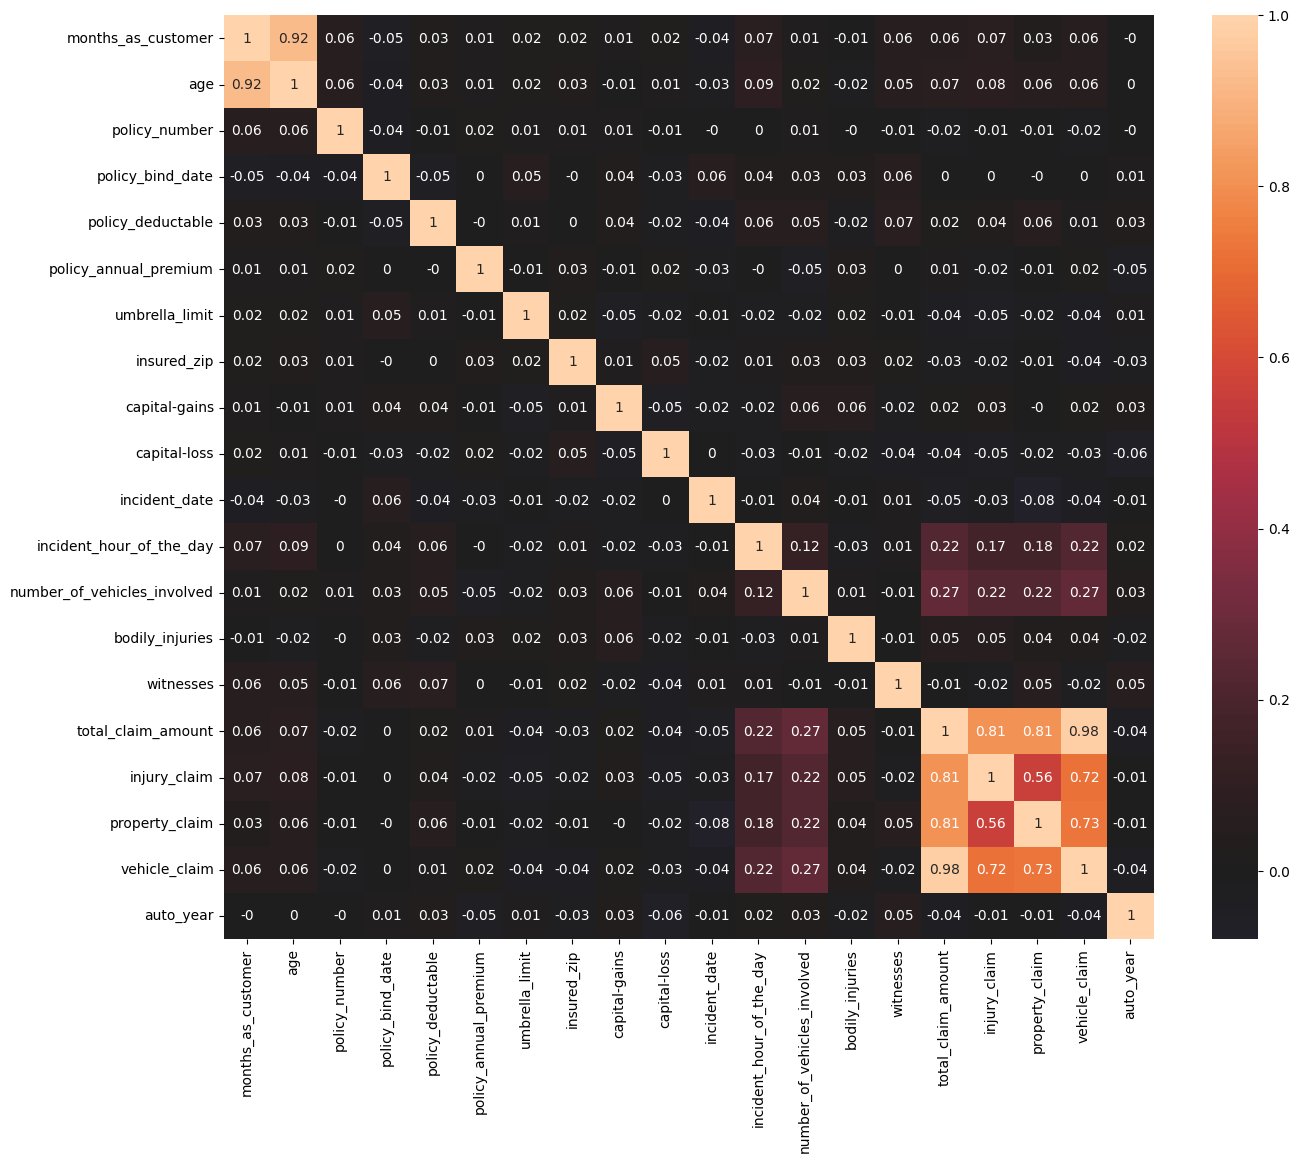

In [15]:
plt.figure(figsize = (15,12))
sns.heatmap(np.round(df[expl_col].corr(),2), annot=True, center =0);

<Axes: ylabel='Frequency'>

<Figure size 1500x1200 with 0 Axes>

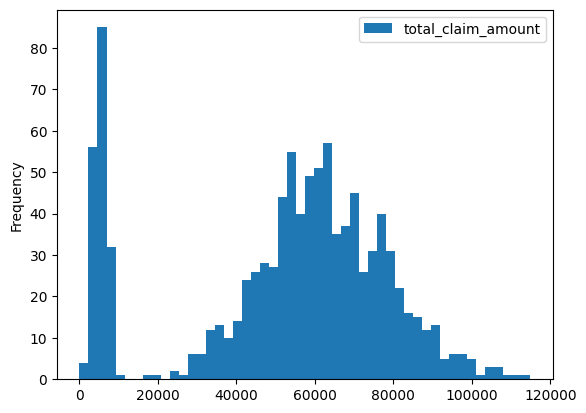

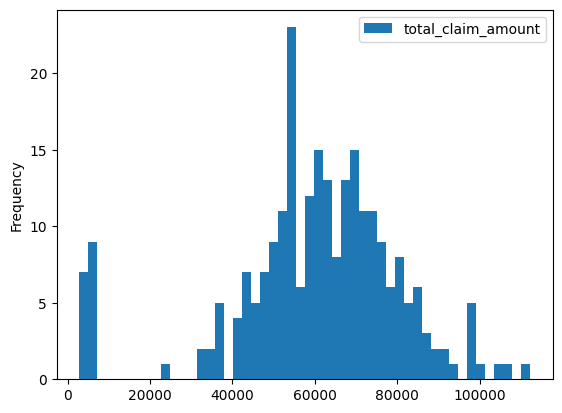

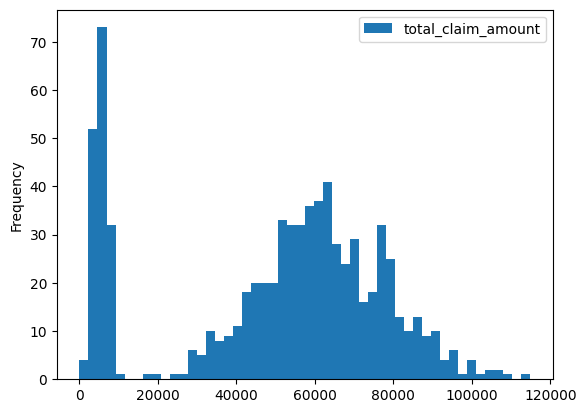

In [38]:
plt.figure(figsize = (15,12))

df.plot.hist(y="total_claim_amount", bins =50)
df[df["fraud"]==1].plot.hist(y="total_claim_amount", bins =50)
df[df["fraud"]==0].plot.hist(y="total_claim_amount", bins =50)


<Axes: xlabel='police_report_available', ylabel='count'>

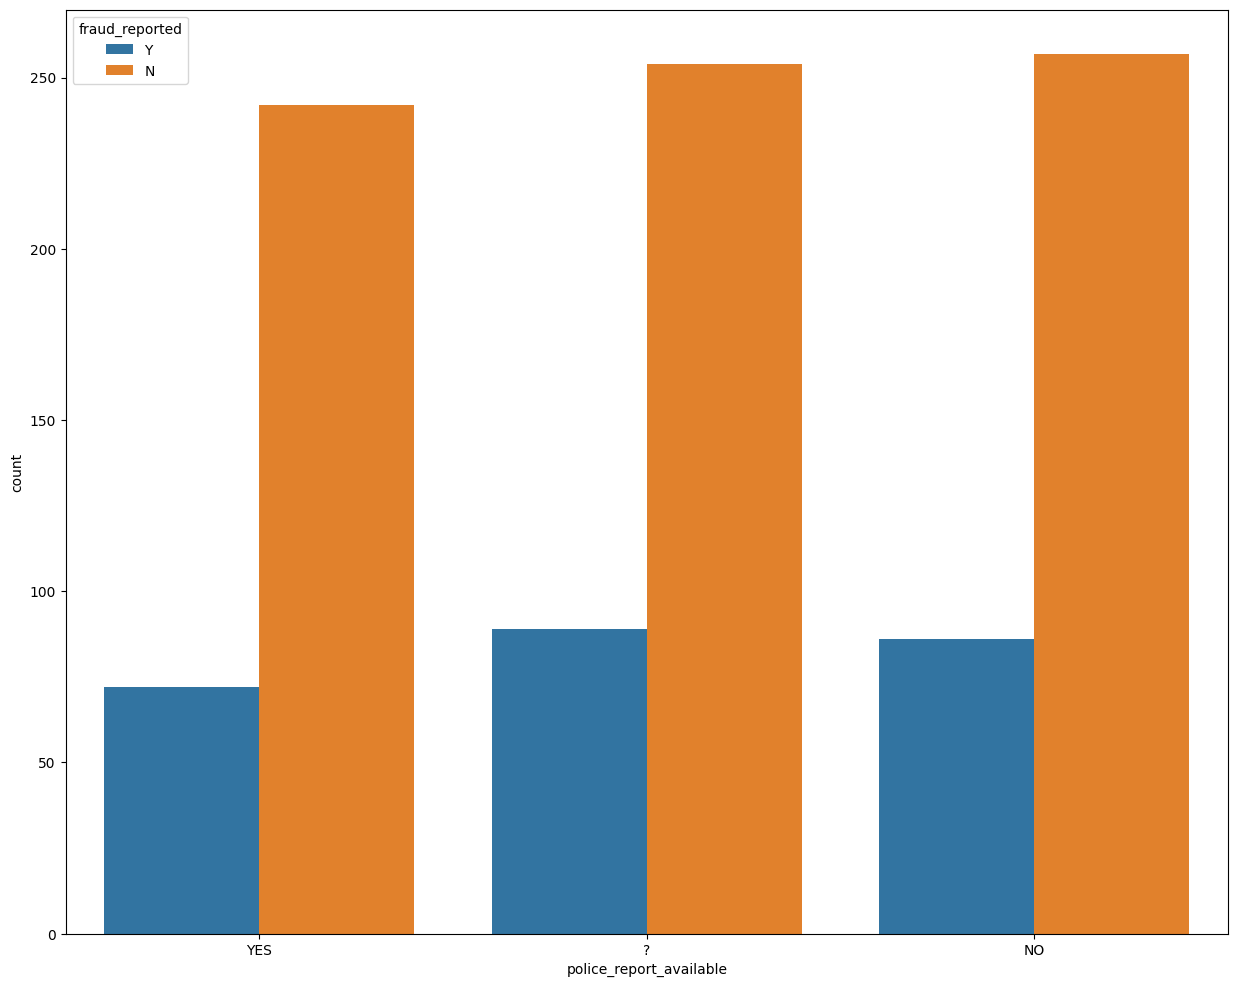

In [46]:
plt.figure(figsize = (15,12))
sns.countplot(x="police_report_available", data = df, hue="fraud_reported")

<Axes: xlabel='authorities_contacted', ylabel='count'>

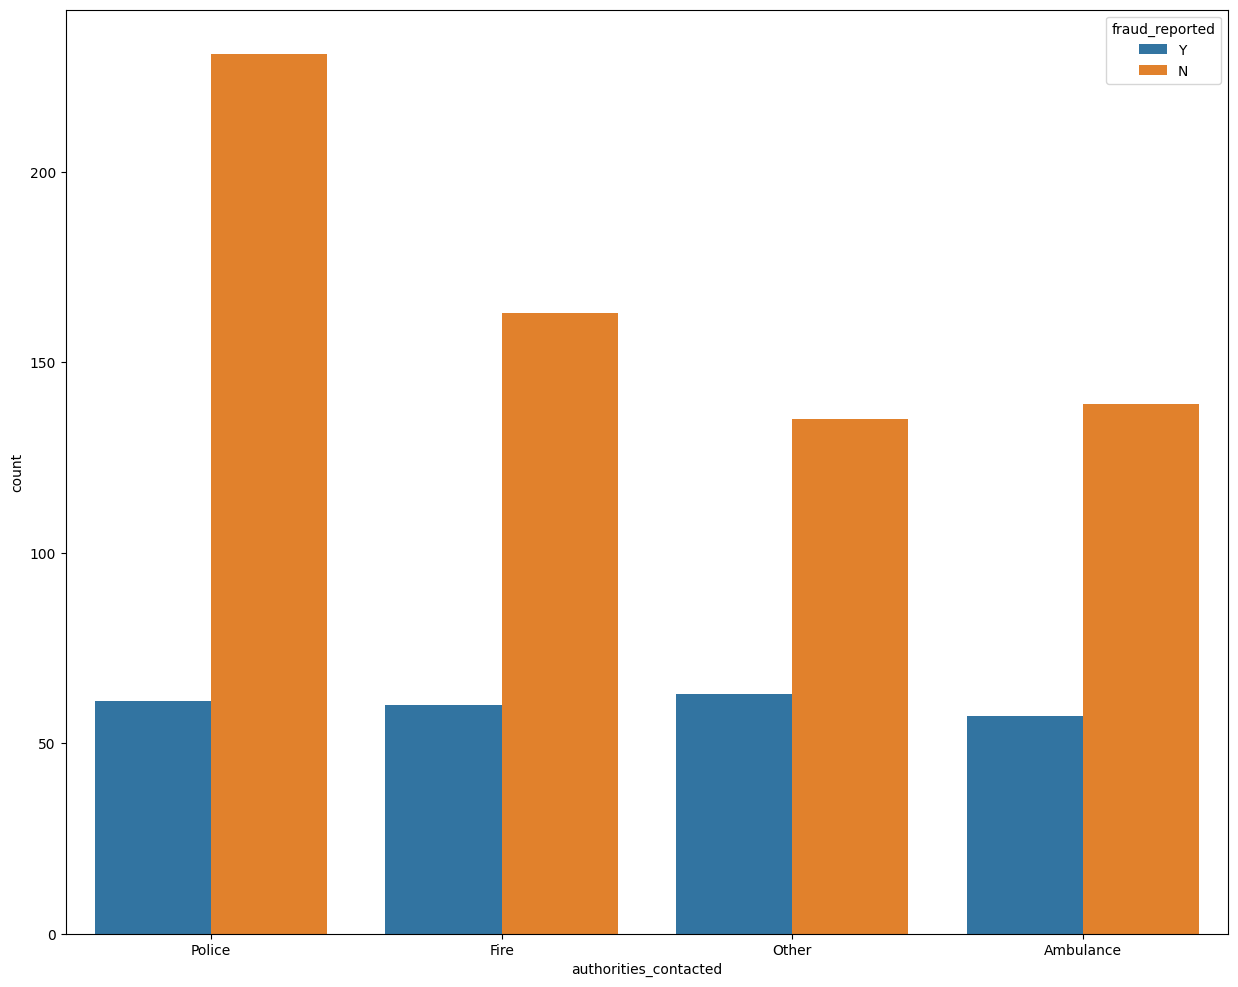

In [47]:
plt.figure(figsize = (15,12))
sns.countplot(x="authorities_contacted", data = df, hue="fraud_reported")

<Axes: xlabel='incident_hour_of_the_day', ylabel='Count'>

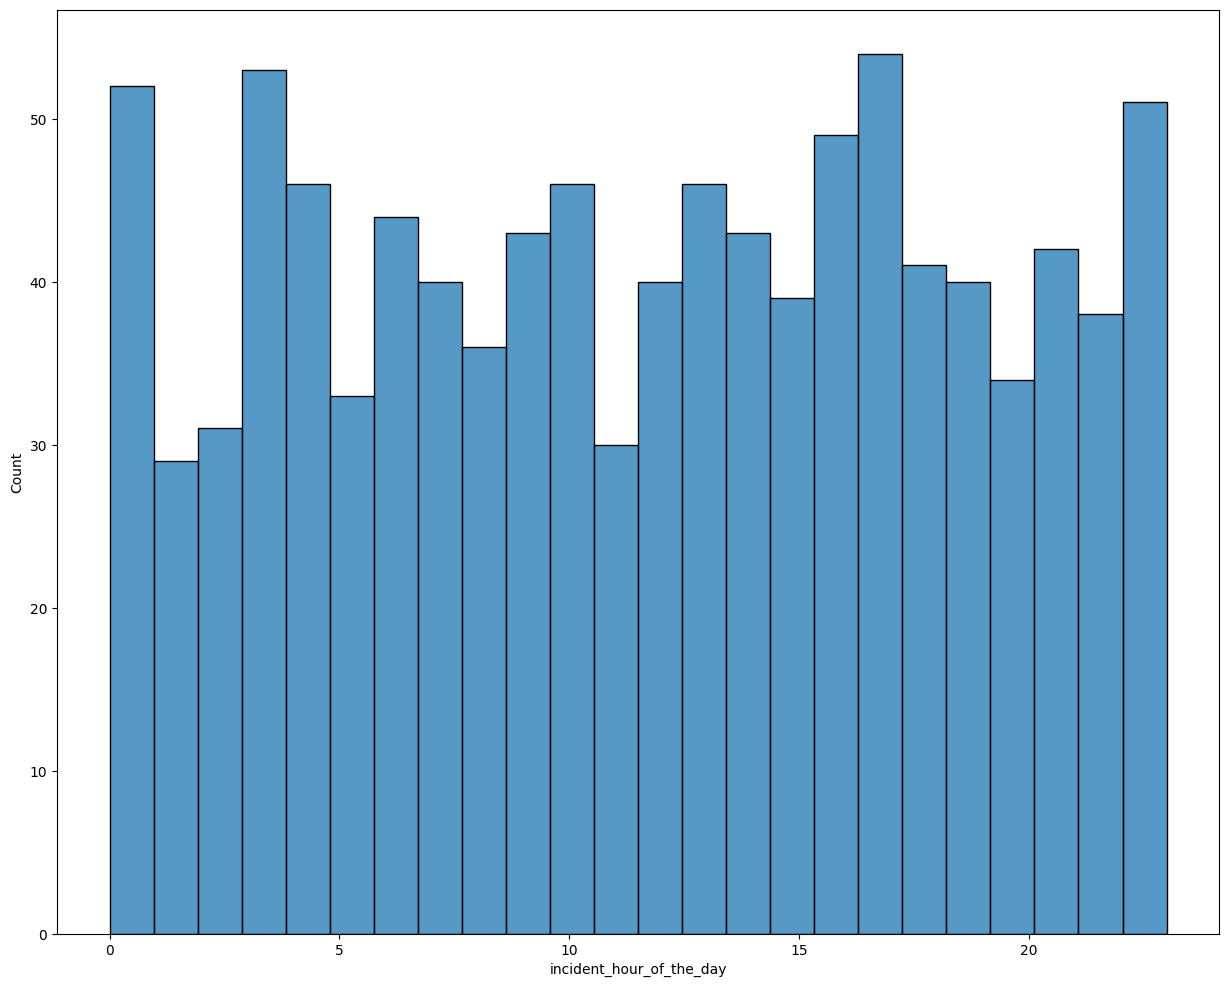

In [53]:
plt.figure(figsize=(15,12))
sns.histplot(df["incident_hour_of_the_day"], bins =24)